# External Boosting and LSTM

## Goal
This notebook finishes the missing work for the advanced-modeling phase using **one split only: the time-aware split**.

Main tasks:
1. Build Feature Sets **A / B / C**
2. Run **XGBoost** sanity fit + early stopping + quick trial sweep
3. Train **LightGBM** and **CatBoost** baselines
4. Generate boosted-model diagnostics and worst-case tables
5. Build a **lag baseline**
6. Train a **tiny LSTM** on country-year sequences
7. Compare lag baseline vs LSTM

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display

from life_expectancy.analysis.diagnostics import (
    group_error_table,
    plot_predicted_vs_actual,
    plot_residual_hist,
    plot_residuals_vs_predicted,
    worst_errors_table,
)
from life_expectancy.data.preprocessing import build_processed_dataset
from life_expectancy.features.feature_selection import (
    build_feature_sets_abc,
    save_feature_sets_json,
)
from life_expectancy.features.temporal import make_country_lag_features
from life_expectancy.modeling.experiments.boosting import (
    run_boosting_time_experiment,
)
from life_expectancy.modeling.experiments.sequence import (
    build_country_sequences,
    run_lstm_time_experiment,
)
from life_expectancy.modeling.experiments.core import run_time_experiment
from life_expectancy.modeling.models.boosting import get_xgb_trial_grid
from life_expectancy.modeling.registries import get_default_model_registry

In [2]:
from life_expectancy.data.utils import resolve_project_path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

config["project"]["root"] = str(PROJECT_ROOT)

PROCESSED = resolve_project_path(config, "data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
TARGET = config["features"].get("target_col", "life_expectancy")
YEAR_COL = config["features"].get("year_col", "year")
TEST_YEARS = config.get("modeling", {}).get("split", {}).get("test_years", 3)
RANDOM_STATE = config.get("random_seed", 42)

TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUN_LOG = TABLES_DIR / "external_boosting_lstm_runs.csv"

sns.set_theme(style="whitegrid")

print("Project root:", PROJECT_ROOT)
print("Target:", TARGET)


Project root: /Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis
Target: life_expectancy


## Load processed dataset
This tries the two most likely processed dataset names used in the repo.

In [3]:
panel, preprocessing_summary = build_processed_dataset(config)

panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="raise").astype(int)

panel.head(), panel.shape

(       country  year      status  life_expectancy_who  adult_mortality  \
 0  Afghanistan  2015  Developing                 65.0            263.0   
 1  Afghanistan  2014  Developing                 59.9            271.0   
 2  Afghanistan  2013  Developing                 59.9            268.0   
 3  Afghanistan  2012  Developing                 59.5            272.0   
 4  Afghanistan  2011  Developing                 59.2            275.0   
 
    infant_deaths  alcohol  percentage_expenditure  hepatitis_b  measles  ...  \
 0             62     0.01               71.279624         65.0      100  ...   
 1             64     0.01               73.523582         62.0      100  ...   
 2             66     0.01               73.219243         64.0      100  ...   
 3             69     0.01               78.184215         67.0      100  ...   
 4             71     0.01                7.097109         68.0      100  ...   
 
            co2  health_expenditure_percent  education_expen

## Build Feature Sets A / B / C
- **A** = full cleaned numeric set
- **B** = correlation-pruned
- **C** = more reduced, VIF-aware, manually interpretable set

In [4]:
model_df, feature_sets, feature_meta = build_feature_sets_abc(panel, config)

feature_summary = pd.DataFrame(
    {
        "feature_set": ["A", "B", "C"],
        "n_features": [
            len(feature_sets["A"]),
            len(feature_sets["B"]),
            len(feature_sets["C"]),
        ],
    }
)

display(feature_summary)

,feature_set,n_features
0,A,38
1,B,31
2,C,5


In [5]:
save_feature_sets_json(
    feature_sets,
    feature_meta,
    TABLES_DIR / "external_feature_sets.json",
)

print("Saved feature sets.")

Saved feature sets.


## XGBoost sanity run
Start with one clean time-aware run on Feature Set B.

In [6]:
boosting_config = config.get("modeling", {}).get("boosting", {})
xgb_config = boosting_config.get("xgb_sanity", {})

if not xgb_config.get("enabled", True):
    print("XGBoost sanity run disabled in config.")
else:
    xgb_feature_set = xgb_config.get("feature_set", "B")
    xgb_params = xgb_config.get("model_params", {}).copy()

    xgb_params["random_state"] = xgb_params.get(
        "random_state",
        RANDOM_STATE,
    )

    xgb_sanity_row, xgb_sanity_pred, xgb_sanity_model, xgb_sanity_prep = (
        run_boosting_time_experiment(
            df=model_df,
            feature_list=feature_sets[xgb_feature_set],
            target_col=TARGET,
            year_col=YEAR_COL,
            model_family=xgb_config.get("model_family", "xgb"),
            model_name=xgb_config.get("model_name", "XGB_sanity"),
            test_years=TEST_YEARS,
            val_years=config.get("modeling", {})
            .get("split", {})
            .get("val_years", 1),
            scale_numeric=xgb_config.get("scale_numeric", "none"),
            model_params=xgb_params,
            run_log_path=RUN_LOG,
            id_cols=[YEAR_COL],
        )
    )

    display(pd.DataFrame([xgb_sanity_row]))

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
0,XGB_sanity,time,1661,151,453,1.696117,1.256609,0.95895,299


## XGBoost quick trial sweep
This is a minimal sweep that includes:
- early stopping,
- depth varied,
- learning rate varied,
- and capacity / subsampling varied.

In [7]:
xgb_trials = get_xgb_trial_grid(random_state=RANDOM_STATE)

xgb_rows = []
xgb_artifacts = {}

for trial in xgb_trials:
    row, pred_df, model, preprocessor = run_boosting_time_experiment(
        df=model_df,
        feature_list=feature_sets["B"],
        target_col=TARGET,
        year_col=YEAR_COL,
        model_family="xgb",
        model_name=trial["trial_name"],
        test_years=TEST_YEARS,
        val_years=1,
        model_params=trial["params"],
        run_log_path=str(RUN_LOG),
        id_cols=[YEAR_COL],
    )
    xgb_rows.append(row)
    xgb_artifacts[trial["trial_name"]] = {
        "pred_df": pred_df,
        "model": model,
        "preprocessor": preprocessor
    }

xgb_results = pd.DataFrame(xgb_rows).sort_values(
    ["rmse", "mae", "r2"],
    ascending=[True, True, False],
)

xgb_results.to_csv(TABLES_DIR / "xgb_trials.csv", index=False)

xgb_results

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
7,xgb_cap_1200_sub0.8_col0.8,time,1661,151,453,1.504393,1.108446,0.967705,924
6,xgb_cap_800_sub0.8_col0.8,time,1661,151,453,1.506839,1.110255,0.967600,796
8,xgb_cap_1500_sub1.0_col0.8,time,1661,151,453,1.557018,1.137524,0.965407,643
2,xgb_depth_7,time,1661,151,453,1.584741,1.171039,0.964164,1118
3,xgb_lr_0.03,time,1661,151,453,1.587525,1.156765,0.964038,1498
1,xgb_depth_5,time,1661,151,453,1.608846,1.186479,0.963065,1065
4,xgb_lr_0.05,time,1661,151,453,1.608846,1.186479,0.963065,1065
5,xgb_lr_0.1,time,1661,151,453,1.610999,1.174983,0.962966,851
0,xgb_depth_3,time,1661,151,453,1.718682,1.282433,0.957850,1126


In [8]:
best_xgb_name = xgb_results.iloc[0]["model_name"]
best_xgb_name

'xgb_cap_1200_sub0.8_col0.8'

## Best XGBoost stability rerun
Re-run the best config with two seeds to check stability.

In [9]:
best_trial = next(
    trial for trial in xgb_trials if trial["trial_name"] == best_xgb_name
)

stability_rows = []

for seed in [42, 43]:
    params = dict(best_trial["params"])
    params["random_state"] = seed

    row, pred_df, model, preprocessor = run_boosting_time_experiment(
        df=model_df,
        feature_list=feature_sets["B"],
        target_col=TARGET,
        year_col=YEAR_COL,
        model_family="xgb",
        model_name=f"{best_xgb_name}_seed{seed}",
        test_years=TEST_YEARS,
        val_years=1,
        scale_numeric="none",
        model_params=params,
        run_log_path=RUN_LOG,
        id_cols=[YEAR_COL],
    )

    stability_rows.append(row)

xgb_stability_df = pd.DataFrame(stability_rows)
xgb_stability_df.to_csv(TABLES_DIR / "xgb_stability.csv", index=False)

xgb_stability_df

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
0,xgb_cap_1200_sub0.8_col0.8_seed42,time,1661,151,453,1.504393,1.108446,0.967705,924
1,xgb_cap_1200_sub0.8_col0.8_seed43,time,1661,151,453,1.511696,1.130143,0.967391,1187


## LightGBM and CatBoost baselines
These are baseline external-boosting comparisons on the same time-aware split and Feature Set B.

In [10]:
boosting_config = config.get("modeling", {}).get("boosting", {})
split_config = config.get("modeling", {}).get("split", {})

VAL_YEARS = split_config.get("val_years", 1)

boost_rows = [xgb_results.iloc[0].to_dict()]
boost_artifacts = {
    best_xgb_name: xgb_artifacts[best_xgb_name]["pred_df"],
}

for config_name in ["lgbm_baseline", "catboost_baseline"]:
    model_config = boosting_config.get(config_name, {})

    if not model_config.get("enabled", False):
        print(f"Skipping {config_name}: disabled in config.")
        continue

    feature_set_name = model_config.get("feature_set", "B")

    row, pred_df, model, preprocessor = run_boosting_time_experiment(
        df=model_df,
        feature_list=feature_sets[feature_set_name],
        target_col=TARGET,
        year_col=YEAR_COL,
        model_family=model_config["model_family"],
        model_name=model_config["model_name"],
        test_years=TEST_YEARS,
        val_years=VAL_YEARS,
        scale_numeric=model_config.get("scale_numeric", "none"),
        model_params=model_config.get("model_params", {}).copy(),
        run_log_path=RUN_LOG,
        id_cols=[YEAR_COL],
    )

    boost_rows.append(row)
    boost_artifacts[row["model_name"]] = pred_df

boost_compare = pd.DataFrame(boost_rows).sort_values(
    ["rmse", "mae", "r2"],
    ascending=[True, True, False],
)

boost_compare.to_csv(
    TABLES_DIR / "external_boosting_compare.csv",
    index=False,
)

boost_compare

/Users/aleksia/Desktop/RND4IMPACT Projects/life-expectancy-analysis/life_exp/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_iteration
0,xgb_cap_1200_sub0.8_col0.8,time,1661,151,453,1.504393,1.108446,0.967705,924
1,LightGBM_baseline,time,1661,151,453,1.645552,1.197233,0.961361,300
2,CatBoost_baseline,time,1661,151,453,1.680190,1.231490,0.959717,299


## Diagnostics for the best boosted model
These plots/tables give you:
- predicted vs actual
- residuals vs predicted
- residual histogram
- top 10 worst country-years
- MAE by region
- MAE by year

In [11]:
best_boost_model_name = boost_compare.iloc[0]["model_name"]
best_boost_pred = boost_artifacts[best_boost_model_name].copy()

worst10_boost = worst_errors_table(best_boost_pred, n=10)
mae_by_year_boost = group_error_table(best_boost_pred, group_col=YEAR_COL)

if "region" in best_boost_pred.columns:
    mae_by_region_boost = group_error_table(
        best_boost_pred,
        group_col="region",
    )
else:
    mae_by_region_boost = None

worst10_boost.to_csv(
    TABLES_DIR / "best_boost_worst10.csv",
    index=False,
)

mae_by_year_boost.to_csv(
    TABLES_DIR / "best_boost_mae_by_year.csv",
    index=False,
)

if mae_by_region_boost is not None:
    mae_by_region_boost.to_csv(
        TABLES_DIR / "best_boost_mae_by_region.csv",
        index=False,
    )

display(worst10_boost)
display(
    mae_by_region_boost.head(10)
    if mae_by_region_boost is not None
    else "No region column"
)
display(mae_by_year_boost.head(10))

,year,y_true,y_pred,error,abs_error
0,2015,51.970500,59.095535,7.125035,7.125035
1,2014,50.236000,56.560532,6.324532,6.324532
2,2013,65.049500,59.389633,-5.659867,5.659867
3,2013,63.440500,58.389435,-5.051065,5.051065
4,2014,85.060976,80.325737,-4.735239,4.735239
5,2013,52.865500,57.363945,4.498445,4.498445
6,2014,54.064500,49.571438,-4.493062,4.493062
7,2014,85.090244,80.611053,-4.479190,4.479190
8,2015,72.070500,76.180458,4.109958,4.109958
9,2015,74.575500,78.600693,4.025193,4.025193


'No region column'

,year,n,mae,rmse
0,2015,151,1.216621,1.635315
1,2014,151,1.123672,1.511466
2,2013,151,0.985045,1.353075


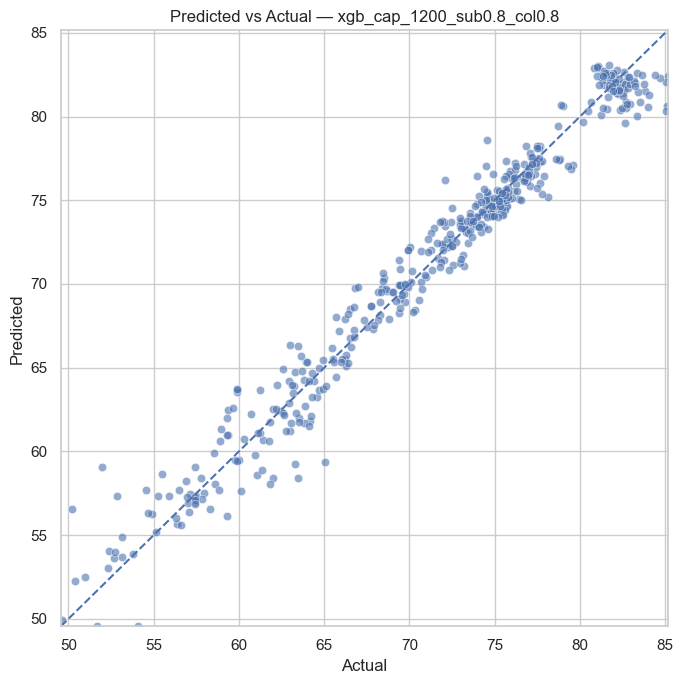

In [12]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_boost_pred, x="y_true", y="y_pred", alpha=0.6)
lims = [
    min(best_boost_pred["y_true"].min(), best_boost_pred["y_pred"].min()),
    max(best_boost_pred["y_true"].max(), best_boost_pred["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual — {best_boost_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week10_best_boost_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

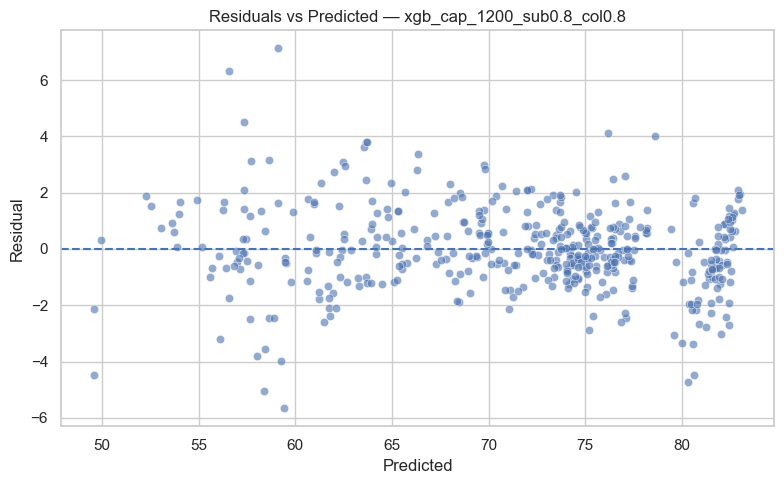

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=best_boost_pred, x="y_pred", y="error", alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title(f"Residuals vs Predicted — {best_boost_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week10_best_boost_residual_vs_pred.png", dpi=200, bbox_inches="tight")
plt.show()

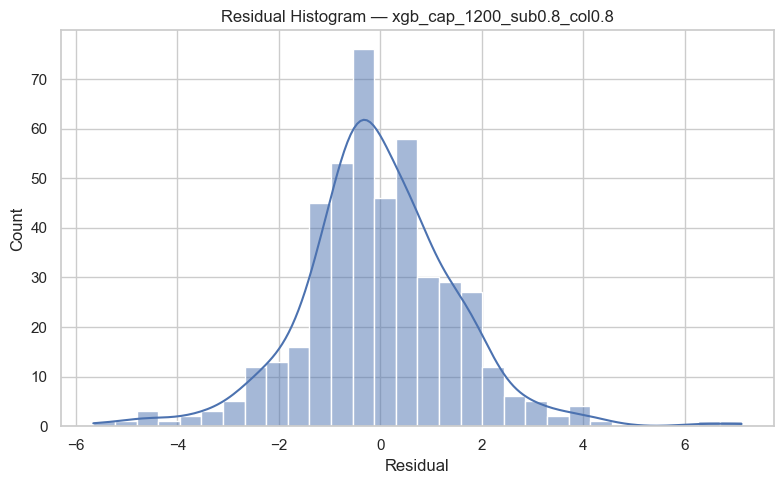

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(best_boost_pred["error"], bins=30, kde=True)
plt.xlabel("Residual")
plt.title(f"Residual Histogram — {best_boost_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week10_best_boost_residual_hist.png", dpi=200, bbox_inches="tight")
plt.show()

## Lag baseline
This is the simpler temporal baseline: previous country-year target and key features are turned into lagged tabular predictors.

In [16]:
metadata_cols = [
    col
    for col in ["country", "country_code", "region", "income_group", YEAR_COL]
    if col in panel.columns
]

metadata = panel[metadata_cols].copy()
metadata[YEAR_COL] = pd.to_numeric(metadata[YEAR_COL], errors="raise").astype(int)

lag_source_df = pd.concat(
    [
        metadata.reset_index(drop=True),
        model_df.reset_index(drop=True),
    ],
    axis=1,
)

lag_source_df = lag_source_df.loc[:, ~lag_source_df.columns.duplicated()]
lag_source_df = lag_source_df.dropna(subset=["country", YEAR_COL, TARGET]).copy()

lag_base_features = [
    feature for feature in feature_sets["C"] if feature not in {YEAR_COL, TARGET}
]

lag_df = make_country_lag_features(
    lag_source_df,
    target_col=TARGET,
    country_col="country",
    year_col=YEAR_COL,
    feature_cols=lag_base_features,
    lags=(1, 2, 3),
    dropna_lagged=True,
)

lag_feature_cols = [
    col
    for col in lag_df.columns
    if col
    not in {
        "country",
        "country_code",
        "region",
        "income_group",
        TARGET,
    }
]

len(lag_feature_cols), lag_df.shape

(55, (1812, 60))

In [17]:
registry = get_default_model_registry(random_state=RANDOM_STATE)

lag_ridge_row, lag_ridge_pred, _, lag_ridge_pipe = run_time_experiment(
    df=lag_df,
    feature_list=lag_feature_cols,
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="LagRidgeCV",
    model=registry["ridge"]["model"],
    scale_numeric=registry["ridge"]["scale_numeric"],
    test_years=TEST_YEARS,
    run_log_path=RUN_LOG,
    split_label="time_lagged",
    id_cols=["country", "country_code", "region", "income_group", YEAR_COL],
)

lag_hgb_row, lag_hgb_pred, _, lag_hgb_pipe = run_time_experiment(
    df=lag_df,
    feature_list=lag_feature_cols,
    target_col=TARGET,
    year_col=YEAR_COL,
    model_name="LagHistGBR",
    model=registry["hgb"]["model"],
    scale_numeric=registry["hgb"]["scale_numeric"],
    test_years=TEST_YEARS,
    run_log_path=RUN_LOG,
    split_label="time_lagged",
    id_cols=["country", "country_code", "region", "income_group", YEAR_COL],
)

lag_compare = pd.DataFrame([lag_ridge_row, lag_hgb_row]).sort_values(
    ["rmse", "mae", "r2"],
    ascending=[True, True, False],
)

lag_compare.to_csv(TABLES_DIR / "lag_model_compare.csv", index=False)

lag_compare

,model_name,split_name,n_train,n_test,rmse,mae,r2
1,LagHistGBR,time_lagged,1359,453,0.782090,0.468453,0.991272
0,LagRidgeCV,time_lagged,1359,453,0.934932,0.532570,0.987527


## LSTM
Main sequence model: country histories are turned into sliding windows and the model predicts next-year life expectancy.

In [18]:
sequence_feature_cols = [
    feature for feature in feature_sets["C"] if feature not in {YEAR_COL, TARGET}
]

sequence_source_cols = list(
    dict.fromkeys(
        [
            *metadata_cols,
            TARGET,
            *sequence_feature_cols,
        ]
    )
)

sequence_source_df = lag_source_df[sequence_source_cols].copy()

x_seq, y_seq, meta_seq, seq_cols = build_country_sequences(
    sequence_source_df,
    feature_cols=sequence_feature_cols,
    target_col=TARGET,
    country_col="country",
    year_col=YEAR_COL,
    window=3,
    include_target_history=True,
)

x_seq.shape, len(seq_cols), seq_cols

((1812, 3, 5),
 5,
 ['life_expectancy',
  'hiv_aids',
  'status_flag',
  'infant_deaths',
  'percentage_expenditure'])

In [19]:
lstm_row, lstm_pred, lstm_model, lstm_scaler, lstm_split = (
    run_lstm_time_experiment(
        x_seq,
        y_seq,
        meta_seq,
        year_col=YEAR_COL,
        test_years=TEST_YEARS,
        val_years=1,
        hidden_size=32,
        num_layers=1,
        learning_rate=1e-3,
        batch_size=64,
        epochs=25,
        patience=5,
        random_state=RANDOM_STATE,
        predict_delta=True,
        target_history_channel=0,
        torch_threads=1,
    )
)

pd.DataFrame([lstm_row])

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_epoch
0,lstm_delta,time_sequence,1208,151,453,1.352221,0.857426,0.973908,23


## Lag baseline vs LSTM

In [20]:
lag_vs_lstm = pd.DataFrame([lag_ridge_row, lag_hgb_row, lstm_row]).sort_values(
    ["rmse", "mae", "r2"],
    ascending=[True, True, False],
)

lag_vs_lstm.to_csv(TABLES_DIR / "lag_vs_lstm.csv", index=False)

lag_vs_lstm

,model_name,split_name,n_train,n_test,rmse,mae,r2,n_val,best_epoch
1,LagHistGBR,time_lagged,1359,453,0.782090,0.468453,0.991272,NaN,NaN
0,LagRidgeCV,time_lagged,1359,453,0.934932,0.532570,0.987527,NaN,NaN
2,lstm_delta,time_sequence,1208,453,1.352221,0.857426,0.973908,151.0,23.0


In [22]:
temporal_predictions = {
    "LagRidgeCV": lag_ridge_pred,
    "LagHistGBR": lag_hgb_pred,
    "LSTM": lstm_pred,
}

best_temporal_name = lag_vs_lstm.iloc[0]["model_name"]
print("Best temporal model:", best_temporal_name)
best_temporal_pred = temporal_predictions[best_temporal_name].copy()

worst10_temporal = worst_errors_table(best_temporal_pred, n=10)
mae_by_year_temporal = group_error_table(
    best_temporal_pred,
    group_col=YEAR_COL,
)

worst10_temporal.to_csv(
    TABLES_DIR / "best_temporal_worst10.csv",
    index=False,
)

mae_by_year_temporal.to_csv(
    TABLES_DIR / "best_temporal_mae_by_year.csv",
    index=False,
)

display(worst10_temporal)
display(mae_by_year_temporal)

Best temporal model: LagHistGBR


,country,year,region,income_group,y_true,y_pred,error,abs_error
0,South Africa,2013,Sub-Saharan Africa,Upper middle income,65.049500,59.982106,-5.067394,5.067394
1,Iraq,2013,Middle East & North Africa,Upper middle income,69.468500,73.395319,3.926819,3.926819
2,Trinidad and Tobago,2013,Latin America & Caribbean,High income,71.791000,75.500971,3.709971,3.709971
3,Germany,2014,Europe & Central Asia,High income,85.045122,81.621000,-3.424122,3.424122
4,Angola,2013,Sub-Saharan Africa,Lower middle income,54.577000,57.434906,2.857906,2.857906
5,Zimbabwe,2015,Sub-Saharan Africa,Lower middle income,63.267000,60.422031,-2.844969,2.844969
6,Uganda,2013,Sub-Saharan Africa,Low income,63.440500,60.612666,-2.827834,2.827834
7,Ukraine,2014,Europe & Central Asia,Lower middle income,74.593293,72.048623,-2.544670,2.544670
8,Finland,2014,Europe & Central Asia,High income,85.090244,82.545579,-2.544665,2.544665
9,Afghanistan,2015,South Asia,Low income,64.188500,61.675884,-2.512616,2.512616


,year,n,mae,rmse
0,2014,151,0.498917,0.796428
1,2013,151,0.491236,0.910115
2,2015,151,0.415204,0.610237


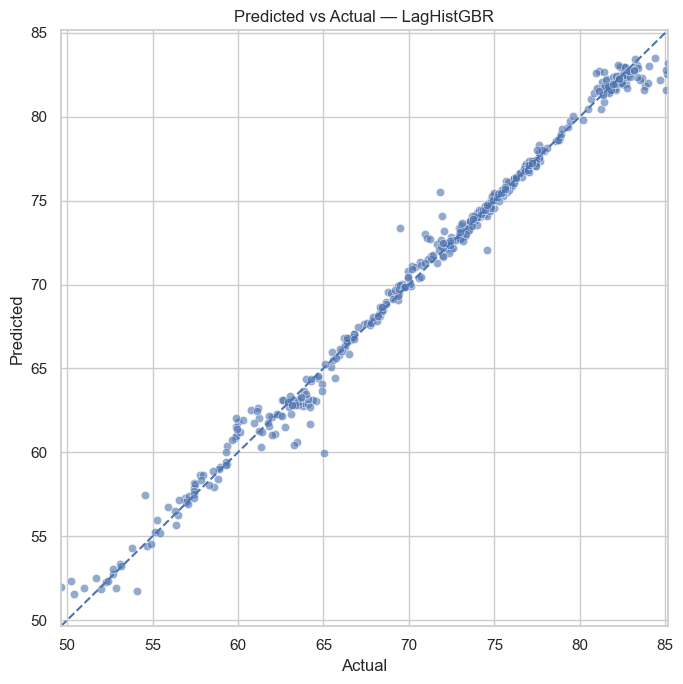

In [23]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_temporal_pred, x="y_true", y="y_pred", alpha=0.6)
lims = [
    min(best_temporal_pred["y_true"].min(), best_temporal_pred["y_pred"].min()),
    max(best_temporal_pred["y_true"].max(), best_temporal_pred["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual — {best_temporal_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "week11_best_temporal_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

## LSTM tuning
Run two small LSTM variants to check whether the poor initial result is due to architecture choice or whether the sequence model is simply not competitive in this low-signal, small-window setting.

In [24]:
variants = [
    {"window": 3, "hidden_size": 32},
    {"window": 5, "hidden_size": 64},
]

lstm_rows = []
lstm_predictions = {}

for variant in variants:
    x_seq, y_seq, meta_seq, seq_cols = build_country_sequences(
        sequence_source_df,
        feature_cols=sequence_feature_cols,
        target_col=TARGET,
        country_col="country",
        year_col=YEAR_COL,
        window=variant["window"],
        include_target_history=True,
    )

    row, pred_df, model, scaler, split = run_lstm_time_experiment(
        x_seq,
        y_seq,
        meta_seq,
        year_col=YEAR_COL,
        test_years=TEST_YEARS,
        val_years=1,
        hidden_size=variant["hidden_size"],
        num_layers=1,
        learning_rate=5e-4,
        batch_size=128,
        epochs=60,
        patience=8,
        random_state=RANDOM_STATE,
        predict_delta=True,
        target_history_channel=0,
        torch_threads=1,
    )

    row["variant"] = f"delta_w{variant['window']}_h{variant['hidden_size']}"
    row["window"] = variant["window"]
    row["hidden_size"] = variant["hidden_size"]

    lstm_rows.append(row)
    lstm_predictions[row["variant"]] = pred_df

lstm_compare = pd.DataFrame(lstm_rows).sort_values("rmse")
lstm_compare.to_csv(TABLES_DIR / "lstm_tuning.csv", index=False)

lstm_compare

,model_name,split_name,n_train,n_val,n_test,rmse,mae,r2,best_epoch,variant,window,hidden_size
1,lstm_delta,time_sequence,906,151,453,1.075997,0.726779,0.983479,60,delta_w5_h64,5,64
0,lstm_delta,time_sequence,1208,151,453,1.303697,0.870987,0.975747,59,delta_w3_h32,3,32
